# Stacking de modelos

Implementamos un enfoque de stacking con el objetivo de combinar modelos cuyos errores sean lo más diversos posible. Esto resulta especialmente adecuado en un problema de clasificación multiclase evaluado mediante Kappa, ya que esta métrica penaliza fuertemente los errores sistemáticos entre clases.

Para esto, seleccionamos modelos de distintas familias (boosting y bagging), buscando que cada uno capture patrones diferentes del dataset. La combinación de estas predicciones a través de un meta-modelo permite mejorar la capacidad de generalización respecto a modelos individuales.

Los modelos base a implementar son:

LightGBM (Boosting)	=> Construye árboles secuencialmente, cada uno corrige los errores del anterior

CatBoost (Boosting)	=>  Boosting especializado en variables categóricas

Random Forest (Bagging) =>	Construye muchos árboles en paralelo sobre muestras aleatorias y promedia

ExtraTreesClassifier (Bagging) => Como Random Forest pero con splits aún más aleatorios (más rápido, más diverso)



Imports de las librerias

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

import optuna

Carga de datos

In [7]:
BASE_DIR = '..'
TARGET = 'AdoptionSpeed'
SEED = 42
N_FOLDS = 5
N_CLASSES = 5

train = pd.read_csv(os.path.join(BASE_DIR, 'work/cleaned/train_X2.csv'))
test  = pd.read_csv(os.path.join(BASE_DIR, 'work/cleaned/test_X2.csv'))

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
y_test  = test[TARGET] if TARGET in test.columns else None
X_test  = test.drop(columns=[TARGET], errors="ignore")

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (11994, 36) | Test: (2999, 36)


## Nested CV (CV anidado)

Para evitar la contaminación entre la optimización de hiperparámetros y la generación de predicciones OOF, implementamos **Nested CV**:

- **Loop externo** (5 folds): define los folds OOF para el stacking.
- **Loop interno** (3 folds + Optuna, 15 trials): para cada fold externo, optimiza los HPs usando **únicamente** los datos de entrenamiento de ese fold.

De esta forma, los HPs de cada modelo se ajustan al mismo subconjunto de datos sobre el cual el modelo luego predice en OOF, eliminando el sesgo optimista que existía antes al optimizar con todo el dataset.

El costo es mayor (5 × 4 modelos × 15 trials × 3 folds internos), pero la estimación de performance es confiable.

In [3]:
from lightgbm import early_stopping as lgbm_es
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

OUTER_FOLDS    = 5
INNER_FOLDS    = 3
N_INNER_TRIALS = 15

outer_skf = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)
inner_skf = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=SEED)

model_names = ['lgbm', 'catboost', 'rf', 'extratrees']
oof_preds  = {name: np.zeros((len(X_train), N_CLASSES)) for name in model_names}
test_preds = {name: np.zeros((len(X_test),  N_CLASSES)) for name in model_names}

for fold, (outer_tr_idx, outer_val_idx) in enumerate(outer_skf.split(X_train, y_train)):
    print(f"\n=== Fold externo {fold+1}/{OUTER_FOLDS} ===")

    X_ftr  = X_train.values[outer_tr_idx]
    X_fval = X_train.values[outer_val_idx]
    y_ftr  = y_train.iloc[outer_tr_idx].reset_index(drop=True)
    y_fval = y_train.iloc[outer_val_idx]

    # ── LGBM ──────────────────────────────────────────────────────────────
    def objective_lgbm(trial):
        params = {
            'learning_rate':     trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
            'max_depth':         trial.suggest_int('max_depth', 4, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
            'n_estimators': 500, 'class_weight': 'balanced',
            'random_state': SEED, 'verbosity': -1,
        }
        kappas = []
        for itr_idx, ival_idx in inner_skf.split(X_ftr, y_ftr):
            m = LGBMClassifier(**params)
            m.fit(X_ftr[itr_idx], y_ftr.iloc[itr_idx],
                  eval_set=[(X_ftr[ival_idx], y_ftr.iloc[ival_idx])],
                  callbacks=[lgbm_es(30, verbose=False)])
            kappas.append(cohen_kappa_score(y_ftr.iloc[ival_idx], m.predict(X_ftr[ival_idx]), weights='quadratic'))
        return np.mean(kappas)

    study_lgbm = optuna.create_study(direction='maximize')
    study_lgbm.optimize(objective_lgbm, n_trials=N_INNER_TRIALS)
    best_lgbm = {**study_lgbm.best_params, 'n_estimators': 500,
                 'class_weight': 'balanced', 'random_state': SEED, 'verbosity': -1}
    mdl_lgbm = LGBMClassifier(**best_lgbm)
    mdl_lgbm.fit(X_ftr, y_ftr)
    oof_preds['lgbm'][outer_val_idx] = mdl_lgbm.predict_proba(X_fval)
    test_preds['lgbm'] += mdl_lgbm.predict_proba(X_test.values) / OUTER_FOLDS
    print(f"  lgbm       kappa fold: {cohen_kappa_score(y_fval, mdl_lgbm.predict(X_fval), weights='quadratic'):.4f}")

    # ── CatBoost ──────────────────────────────────────────────────────────
    def objective_catboost(trial):
        params = {
            'iterations':          trial.suggest_int('iterations', 100, 500),
            'learning_rate':       trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'depth':               trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 0.5, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'early_stopping_rounds': 30,
            'random_state': SEED, 'verbose': 0,
        }
        kappas = []
        for itr_idx, ival_idx in inner_skf.split(X_ftr, y_ftr):
            m = CatBoostClassifier(**params)
            m.fit(X_ftr[itr_idx], y_ftr.iloc[itr_idx],
                  eval_set=(X_ftr[ival_idx], y_ftr.iloc[ival_idx]))
            kappas.append(cohen_kappa_score(y_ftr.iloc[ival_idx], m.predict(X_ftr[ival_idx]), weights='quadratic'))
        return np.mean(kappas)

    study_cb = optuna.create_study(direction='maximize')
    study_cb.optimize(objective_catboost, n_trials=N_INNER_TRIALS)
    best_cb = {**study_cb.best_params, 'early_stopping_rounds': 30, 'random_state': SEED, 'verbose': 0}
    mdl_cb = CatBoostClassifier(**best_cb)
    mdl_cb.fit(X_ftr, y_ftr)
    oof_preds['catboost'][outer_val_idx] = mdl_cb.predict_proba(X_fval)
    test_preds['catboost'] += mdl_cb.predict_proba(X_test.values) / OUTER_FOLDS
    print(f"  catboost   kappa fold: {cohen_kappa_score(y_fval, mdl_cb.predict(X_fval), weights='quadratic'):.4f}")

    # ── Random Forest ─────────────────────────────────────────────────────
    def objective_rf(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 400),
            'max_depth':         trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'class_weight':      trial.suggest_categorical('class_weight', [None, 'balanced']),
            'random_state': SEED, 'n_jobs': -1,
        }
        kappas = []
        for itr_idx, ival_idx in inner_skf.split(X_ftr, y_ftr):
            m = RandomForestClassifier(**params)
            m.fit(X_ftr[itr_idx], y_ftr.iloc[itr_idx])
            kappas.append(cohen_kappa_score(y_ftr.iloc[ival_idx], m.predict(X_ftr[ival_idx]), weights='quadratic'))
        return np.mean(kappas)

    study_rf = optuna.create_study(direction='maximize')
    study_rf.optimize(objective_rf, n_trials=N_INNER_TRIALS)
    best_rf = {**study_rf.best_params, 'random_state': SEED, 'n_jobs': -1}
    mdl_rf = RandomForestClassifier(**best_rf)
    mdl_rf.fit(X_ftr, y_ftr)
    oof_preds['rf'][outer_val_idx] = mdl_rf.predict_proba(X_fval)
    test_preds['rf'] += mdl_rf.predict_proba(X_test.values) / OUTER_FOLDS
    print(f"  rf         kappa fold: {cohen_kappa_score(y_fval, mdl_rf.predict(X_fval), weights='quadratic'):.4f}")

    # ── ExtraTrees ────────────────────────────────────────────────────────
    def objective_et(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 400),
            'max_depth':         trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'class_weight':      trial.suggest_categorical('class_weight', [None, 'balanced']),
            'random_state': SEED, 'n_jobs': -1,
        }
        kappas = []
        for itr_idx, ival_idx in inner_skf.split(X_ftr, y_ftr):
            m = ExtraTreesClassifier(**params)
            m.fit(X_ftr[itr_idx], y_ftr.iloc[itr_idx])
            kappas.append(cohen_kappa_score(y_ftr.iloc[ival_idx], m.predict(X_ftr[ival_idx]), weights='quadratic'))
        return np.mean(kappas)

    study_et = optuna.create_study(direction='maximize')
    study_et.optimize(objective_et, n_trials=N_INNER_TRIALS)
    best_et = {**study_et.best_params, 'random_state': SEED, 'n_jobs': -1}
    mdl_et = ExtraTreesClassifier(**best_et)
    mdl_et.fit(X_ftr, y_ftr)
    oof_preds['extratrees'][outer_val_idx] = mdl_et.predict_proba(X_fval)
    test_preds['extratrees'] += mdl_et.predict_proba(X_test.values) / OUTER_FOLDS
    print(f"  extratrees kappa fold: {cohen_kappa_score(y_fval, mdl_et.predict(X_fval), weights='quadratic'):.4f}")

print("\n=== OOF Kappa por modelo ===")
for name in model_names:
    k = cohen_kappa_score(y_train, oof_preds[name].argmax(axis=1), weights='quadratic')
    print(f"  {name}: {k:.4f}")



=== Fold externo 1/5 ===
  lgbm       kappa fold: 0.3797
  catboost   kappa fold: 0.3957
  rf         kappa fold: 0.3767
  extratrees kappa fold: 0.3473

=== Fold externo 2/5 ===
  lgbm       kappa fold: 0.3999
  catboost   kappa fold: 0.3913
  rf         kappa fold: 0.3644
  extratrees kappa fold: 0.3226

=== Fold externo 3/5 ===
  lgbm       kappa fold: 0.3681
  catboost   kappa fold: 0.3664
  rf         kappa fold: 0.3618
  extratrees kappa fold: 0.3538

=== Fold externo 4/5 ===
  lgbm       kappa fold: 0.3938
  catboost   kappa fold: 0.3700
  rf         kappa fold: 0.3680
  extratrees kappa fold: 0.3446

=== Fold externo 5/5 ===
  lgbm       kappa fold: 0.3931
  catboost   kappa fold: 0.3769
  rf         kappa fold: 0.3580
  extratrees kappa fold: 0.3432

=== OOF Kappa por modelo ===
  lgbm: 0.3870
  catboost: 0.3801
  rf: 0.3659
  extratrees: 0.3423


Construcción de meta-features

In [18]:
oof_preds

{'lgbm': array([[2.55470620e-02, 2.12815977e-01, 2.33048096e-01, 2.29672055e-01,
         2.98916810e-01],
        [3.21709881e-04, 9.96831761e-02, 1.09639934e-01, 4.88181545e-01,
         3.02173635e-01],
        [3.09088294e-01, 1.92027048e-01, 2.21169965e-01, 1.38231828e-01,
         1.39482866e-01],
        ...,
        [6.53896885e-02, 4.27106107e-01, 2.94702626e-01, 1.04911236e-01,
         1.07890341e-01],
        [6.41333720e-04, 3.32788474e-01, 5.64508036e-01, 9.15817240e-02,
         1.04804323e-02],
        [3.73149071e-02, 1.94203218e-02, 4.06172140e-01, 5.22318239e-02,
         4.84860807e-01]]),
 'catboost': array([[0.00891496, 0.27344848, 0.20028431, 0.2075516 , 0.30980066],
        [0.00897667, 0.05204307, 0.1195086 , 0.18867858, 0.63079308],
        [0.03093756, 0.21305115, 0.34097479, 0.1962928 , 0.21874369],
        ...,
        [0.03290534, 0.3012564 , 0.38016862, 0.1277003 , 0.15796933],
        [0.01769348, 0.24193291, 0.45376257, 0.22072224, 0.0658888 ],
        

In [8]:
meta_train = np.hstack([oof_preds[name]  for name in model_names])
meta_test  = np.hstack([test_preds[name] for name in model_names])

print(f"Meta-features train: {meta_train.shape}")  
print(f"Meta-features test:  {meta_test.shape}")


Meta-features train: (11994, 20)
Meta-features test:  (2999, 20)


 Meta-modelo

In [9]:
meta_model = LogisticRegression(max_iter=1000, random_state=SEED)
meta_model.fit(meta_train, y_train)

y_pred_oof   = meta_model.predict(meta_train)
y_pred_final = meta_model.predict(meta_test)

kappa_oof = cohen_kappa_score(y_train, y_pred_oof, weights='quadratic')
print(f"Kappa OOF meta-modelo: {kappa_oof:.4f}")

if y_test is not None:
    kappa_test = cohen_kappa_score(y_test, y_pred_final, weights="quadratic")
    print(f"Kappa TEST  meta-modelo: {kappa_test:.4f}")


Kappa OOF meta-modelo: 0.4153
Kappa TEST  meta-modelo: 0.3830


### Meta-modelos adicionales: Ridge y LGBM ligero

In [11]:
from sklearn.linear_model import RidgeClassifierCV

# ── Ridge (selecciona alpha automáticamente via CV interno) ────────────────────
ridge_meta = RidgeClassifierCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_meta.fit(meta_train, y_train)

y_pred_ridge_oof   = ridge_meta.predict(meta_train)
y_pred_ridge_final = ridge_meta.predict(meta_test)

kappa_ridge_oof  = cohen_kappa_score(y_train, y_pred_ridge_oof,   weights='quadratic')
kappa_ridge_test = cohen_kappa_score(y_test,  y_pred_ridge_final, weights='quadratic')
print(f"Ridge    | alpha={ridge_meta.alpha_:.4f} | OOF: {kappa_ridge_oof:.4f} | TEST: {kappa_ridge_test:.4f}")

# ── LGBM ligero ────────────────────────────────────────────────────────────────
lgbm_meta = LGBMClassifier(
    n_estimators=100, max_depth=3, num_leaves=15,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    class_weight='balanced', random_state=SEED, verbosity=-1,
)
lgbm_meta.fit(meta_train, y_train)

y_pred_lgbm_oof   = lgbm_meta.predict(meta_train)
y_pred_lgbm_final = lgbm_meta.predict(meta_test)

kappa_lgbm_oof  = cohen_kappa_score(y_train, y_pred_lgbm_oof,   weights='quadratic')
kappa_lgbm_test = cohen_kappa_score(y_test,  y_pred_lgbm_final, weights='quadratic')
print(f"LGBM     |             | OOF: {kappa_lgbm_oof:.4f} | TEST: {kappa_lgbm_test:.4f}")

# ── Comparación de los tres meta-modelos ───────────────────────────────────────
print(f"\nResumen meta-modelos:")
print(f"  LogisticRegression | OOF: {kappa_oof:.4f}  | TEST: {kappa_test:.4f}")
print(f"  Ridge              | OOF: {kappa_ridge_oof:.4f}  | TEST: {kappa_ridge_test:.4f}")
print(f"  LGBM ligero        | OOF: {kappa_lgbm_oof:.4f}  | TEST: {kappa_lgbm_test:.4f}")


Ridge    | alpha=10.0000 | OOF: 0.3992 | TEST: 0.3740
LGBM     |             | OOF: 0.3887 | TEST: 0.3254

Resumen meta-modelos:
  LogisticRegression | OOF: 0.4153  | TEST: 0.3830
  Ridge              | OOF: 0.3992  | TEST: 0.3740
  LGBM ligero        | OOF: 0.3887  | TEST: 0.3254


In [12]:
from collections import Counter

print("Kappa individual en TEST:")
for name in model_names:
    base_preds = test_preds[name].argmax(axis=1)
    k = cohen_kappa_score(y_test, base_preds, weights='quadratic')
    print(f"  {name}: {k:.4f}  | pred dist: {dict(sorted(Counter(base_preds).items()))}")


Kappa individual en TEST:
  lgbm: 0.3610  | pred dist: {0: 62, 1: 726, 2: 639, 3: 488, 4: 1084}
  catboost: 0.3488  | pred dist: {0: 2, 1: 552, 2: 824, 3: 304, 4: 1317}
  rf: 0.3577  | pred dist: {0: 19, 1: 741, 2: 601, 3: 391, 4: 1247}
  extratrees: 0.3436  | pred dist: {0: 4, 1: 580, 2: 834, 3: 303, 4: 1278}


In [14]:
import sys
sys.path.append("..")
from tutoriales.utils import plot_confusion_matrix

labels = list(range(N_CLASSES))

# Matriz de confusion del meta-modelo (LogisticRegression)
fig = plot_confusion_matrix(y_test, y_pred_final, labels=labels,
                            title="Meta-modelo: LogisticRegression")
fig.show()

# Matrices de confusion de los modelos base
for name in model_names:
    preds_base = np.argmax(test_preds[name], axis=1)
    fig = plot_confusion_matrix(y_test, preds_base, labels=labels,
                                title=f"Modelo base: {name}")
    fig.show()


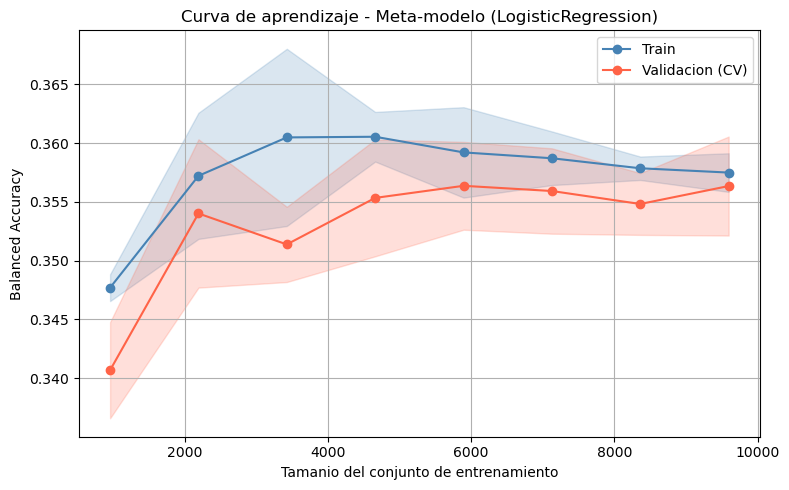

Train final: 0.3575 +/- 0.0016
Val   final: 0.3563 +/- 0.0042
Gap train-val: 0.0011


In [17]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000), meta_train, y_train,
    cv=5, scoring="balanced_accuracy", train_sizes=np.linspace(0.1, 1.0, 8)
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", label="Train", color="steelblue")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="steelblue")
ax.plot(train_sizes, val_mean, "o-", label="Validacion (CV)", color="tomato")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="tomato")
ax.set_xlabel("Tamanio del conjunto de entrenamiento")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Curva de aprendizaje - Meta-modelo (LogisticRegression)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Train final: {train_mean[-1]:.4f} +/- {train_std[-1]:.4f}")
print(f"Val   final: {val_mean[-1]:.4f} +/- {val_std[-1]:.4f}")
print(f"Gap train-val: {train_mean[-1] - val_mean[-1]:.4f}")
